In [1]:
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.quantum_info import Operator, Statevector
import numpy as np

import Elementary_circuits.subarithmetic_circuits as subarithmetic_circuits

# Elementary gate implementation Notebook
I'm trying to build our circuits from the ground up, starting with purely the Clifford + T gates and no others (even the built in Qiskit gates) to get an understanding of the real factors on the complexity of performing the block-encodings in our QPE algorithm

Allowed gates are Clifford gates: H, S, X, Y, Z, I, CNOT and all of their inverses  (add to this list any other Clifford gate I need, this isn't meant to be exhaustive)

and the only non-Clifford gate allowed is T

These are the implementations for the "sub-arithmetic" gates, gates needed to do more complex operations but lower level than real arithmetic (with addition being the lowest level arithmetic)

# V Gate

[[0.5+0.5j 0.5-0.5j]
 [0.5-0.5j 0.5+0.5j]]
The circuit implements the V gate correctly.


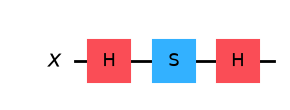

In [11]:
x = QuantumRegister(1, 'x') # main qubits being acted on

qc = QuantumCircuit(x)

gate_counts = [0, 0] # [clifford_count, t_count]
subarithmetic_circuits.V_gate(qc, x, gate_counts)

# get the unitary of the circuit
U = Operator(qc).data
print(U)
if(np.allclose(U, np.array([[0.5+0.5j, 0.5-0.5j], [0.5-0.5j, 0.5+0.5j]]))):
    print("The circuit implements the V gate correctly.")
else:
    raise ValueError("The circuit does not implement the V gate correctly.")

qc.draw('mpl')

# V dagger gate

[[0.5-0.5j 0.5+0.5j]
 [0.5+0.5j 0.5-0.5j]]
The circuit implements the V-dagger gate correctly.


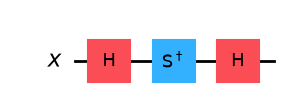

In [12]:
x = QuantumRegister(1, 'x') # main qubits being acted on

qc = QuantumCircuit(x)

gate_counts = [0, 0] # [clifford_count, t_count]
subarithmetic_circuits.V_gate(qc, x, dagger=True, gate_counts=gate_counts)

# get the unitary of the circuit
U = Operator(qc).data
print(U)
if(np.allclose(U, np.array([[0.5-0.5j, 0.5+0.5j], [0.5+0.5j, 0.5-0.5j]]))):
    print("The circuit implements the V-dagger gate correctly.")
else:
    raise ValueError("The circuit does not implement the V-dagger gate correctly.")

qc.draw('mpl')

# Controlled S Gate

Controlled S Gate:  [[1.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 1.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 1.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+1.j]]
The circuit implements the Controlled S gate correctly.


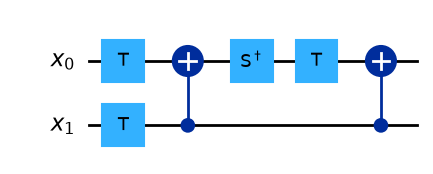

In [15]:
x = QuantumRegister(2, 'x') # main qubits being acted on

qc = QuantumCircuit(x)

gate_counts = [0, 0] # [clifford_count, t_count]
subarithmetic_circuits.CS_gate(qc, x, gate_counts=gate_counts)


# get the unitary of the circuit
U = Operator(qc).data
print("Controlled S Gate: ", np.round(U, decimals=2))
if(np.allclose(U, np.array([[1,0,0,0], [0,1,0,0], [0,0,1,0], [0,0,0,1j]]))):
    print("The circuit implements the Controlled S gate correctly.")
else:
    raise ValueError("The circuit does not implement the Controlled S gate correctly.")


qc.draw('mpl')

# Controlled S_dagger Gate

Controlled S_dagger Gate:  [[1.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 1.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 1.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.-1.j]]
The circuit implements the Controlled S_dagger gate correctly.


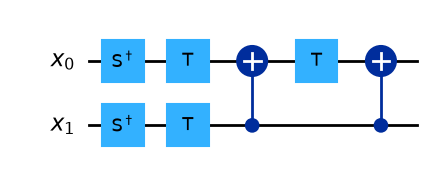

In [16]:
x = QuantumRegister(2, 'x') # main qubits being acted on

qc = QuantumCircuit(x)

gate_counts = [0, 0] # [clifford_count, t_count]
subarithmetic_circuits.CS_gate(qc, x, gate_counts=gate_counts, dagger=True)


# get the unitary of the circuit
U = Operator(qc).data
print("Controlled S_dagger Gate: ", np.round(U, decimals=2))
if(np.allclose(U, np.array([[1,0,0,0], [0,1,0,0], [0,0,1,0], [0,0,0,-1j]]))):
    print("The circuit implements the Controlled S_dagger gate correctly.")
else:
    raise ValueError("The circuit does not implement the Controlled S_dagger gate correctly.")


qc.draw('mpl')

# Controlled V Gate

Controlled V Gate:  [[1. +0.j  0. +0.j  0. +0.j  0. +0.j ]
 [0. +0.j  1. +0.j  0. +0.j  0. +0.j ]
 [0. +0.j  0. +0.j  0.5+0.5j 0.5-0.5j]
 [0. +0.j  0. +0.j  0.5-0.5j 0.5+0.5j]]
The circuit implements the Controlled V gate correctly.


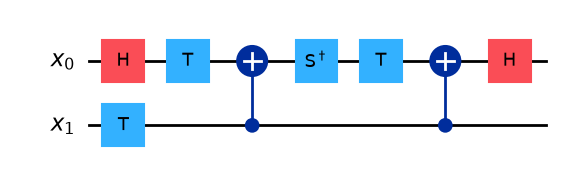

In [17]:
x = QuantumRegister(2, 'x') # main qubits being acted on

qc = QuantumCircuit(x)

gate_counts = [0, 0] # [clifford_count, t_count]
subarithmetic_circuits.CV_gate(qc, x, gate_counts=gate_counts)


# get the unitary of the circuit
U = Operator(qc).data
print("Controlled V Gate: ", np.round(U, decimals=2))
if(np.allclose(U, np.array([[1,0,0,0], [0,1,0,0], [0,0,0.5+0.5j,0.5-0.5j], [0,0,0.5-0.5j,0.5+0.5j]]))):
    print("The circuit implements the Controlled V gate correctly.")
else:
    raise ValueError("The circuit does not implement the Controlled V gate correctly.")


qc.draw('mpl')

# Controlled V_dagger Gate

Controlled V_dagger Gate:  [[1. +0.j  0. +0.j  0. +0.j  0. +0.j ]
 [0. +0.j  1. +0.j  0. +0.j  0. +0.j ]
 [0. +0.j  0. +0.j  0.5-0.5j 0.5+0.5j]
 [0. +0.j  0. +0.j  0.5+0.5j 0.5-0.5j]]
The circuit implements the Controlled V_dagger gate correctly.


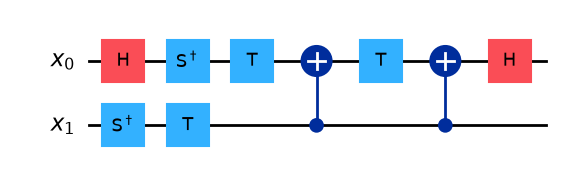

In [18]:
x = QuantumRegister(2, 'x') # main qubits being acted on

qc = QuantumCircuit(x)

gate_counts = [0, 0] # [clifford_count, t_count]
subarithmetic_circuits.CV_gate(qc, x, gate_counts=gate_counts, dagger=True)

# get the unitary of the circuit
U = Operator(qc).data
print("Controlled V_dagger Gate: ", np.round(U, decimals=2))
if(np.allclose(U, np.array([[1,0,0,0], [0,1,0,0], [0,0,0.5-0.5j,0.5+0.5j], [0,0,0.5+0.5j,0.5-0.5j]]))):
    print("The circuit implements the Controlled V_dagger gate correctly.")
else:
    raise ValueError("The circuit does not implement the Controlled V gate correctly.")


qc.draw('mpl')

# Toffoli Gate

[[1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j]]
The circuit implements the Toffoli gate correctly.


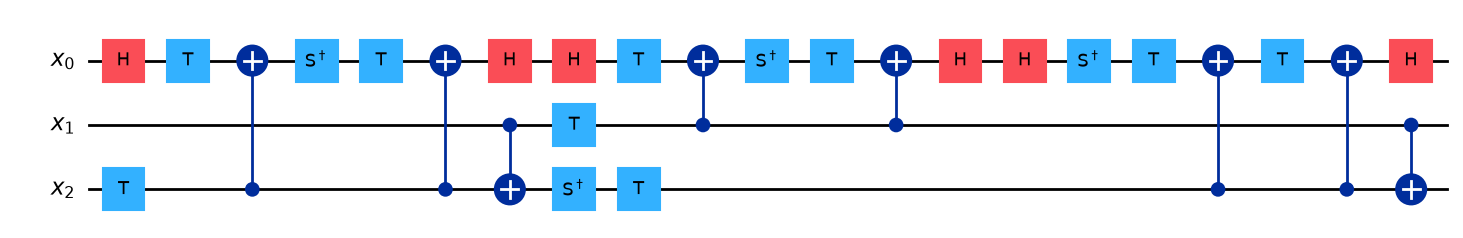

In [21]:
x = QuantumRegister(3, 'x') # main qubits being acted on

qc = QuantumCircuit(x)

gate_counts = [0, 0] # [clifford_count, t_count]
subarithmetic_circuits.Toffoli_gate(qc, x, gate_counts=gate_counts)

# get the unitary of the circuit
U = Operator(qc).data
print(np.round(U, decimals=2))
if(np.allclose(U, np.array([[1,0,0,0,0,0,0,0],[0,1,0,0,0,0,0,0],[0,0,1,0,0,0,0,0],[0,0,0,1,0,0,0,0],[0,0,0,0,1,0,0,0],[0,0,0,0,0,1,0,0],[0,0,0,0,0,0,0,1],[0,0,0,0,0,0,1,0]]))):
    print("The circuit implements the Toffoli gate correctly.")
else:
    raise ValueError("The circuit does not implement the Toffoli gate correctly.")

qc.draw('mpl')

# Peres Gate

[[1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j]]
The circuit implements the Peres gate correctly.


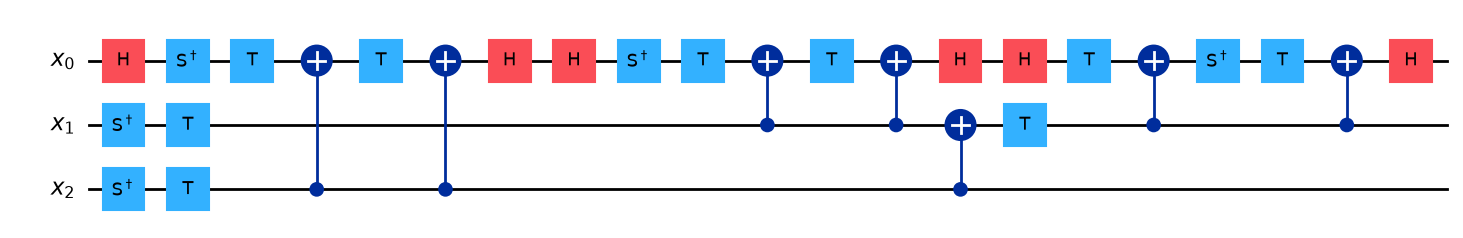

In [23]:
x = QuantumRegister(3, 'x') # main qubits being acted on

qc = QuantumCircuit(x)

gate_counts = [0, 0] # [clifford_count, t_count]
subarithmetic_circuits.Peres_gate(qc, x, gate_counts=gate_counts, useElementaryGates=True)

# get the unitary of the circuit
U = Operator(qc).data
print(np.round(U, decimals=2))
if(np.allclose(U, np.array([[1,0,0,0,0,0,0,0],[0,1,0,0,0,0,0,0],[0,0,1,0,0,0,0,0],[0,0,0,1,0,0,0,0],[0,0,0,0,0,0,0,1],[0,0,0,0,0,0,1,0],[0,0,0,0,1,0,0,0],[0,0,0,0,0,1,0,0]]))):
    print("The circuit implements the Peres gate correctly.")
else:
    raise ValueError("The circuit does not implement the Peres gate correctly.")

qc.draw('mpl')